In [260]:
# =========================
# SECTION 2: IMPORTS + CONFIG
# =========================

import pandas as pd
import numpy as np
from datetime import datetime
import yfinance as yf

# Data settings
DATA_PERIOD = "10y"
DATA_INTERVAL = "1d"

# Indicator settings
MOMENTUM_WINDOW = 20
VOLUME_WINDOW = 20
VOLATILITY_WINDOW = 20
SHORT_SMA_WINDOW = 20
LONG_SMA_WINDOW = 50

# Strategy thresholds
MIN_MOMENTUM_20D = 0.05       # +5% over 20 trading days
MIN_VOLUME_RATIO = 1.00       # today's volume >= 20-day average volume
MAX_VOLATILITY_20D = 0.03     # daily return standard deviation below 3%

# Risk/liquidity settings
MIN_AVG_DOLLAR_VOLUME = 10_000_000  # $10 million average daily dollar volume

# Disaster kill switch setting
DISASTER_DRAWDOWN_LIMIT = 0.2       # 20% daily equity drop

print("Config loaded.")

Config loaded.


In [261]:
# %%
# =========================
# SECTION 1: STOCK UNIVERSE CONFIG
# =========================

UNIVERSE_MODE = "LIVE"      # "LIVE" or "BACKTEST_2016"

LIVE_STOCK_UNIVERSE = {
    "AAPL": "Technology",
    "MSFT": "Technology",
    "NVDA": "Technology",
    "AVGO": "Technology",
    "AMD": "Technology",
    "ARM": "Technology",
    "PLTR": "Technology",
    "COIN": "Financials",
    "HOOD": "Financials",
    "APP": "Technology",
    "VRT": "Industrials",
    "CRWD": "Technology",
    "DDOG": "Technology",
    "TTD": "Communication Services",
    # keep the rest of your current live universe here
}

BACKTEST_2016_UNIVERSE = {
    # Technology
    "AAPL": "Technology",
    "MSFT": "Technology",
    "GOOGL": "Communication Services",
    "GOOG": "Communication Services",
    "META": "Communication Services",
    "AMZN": "Consumer Discretionary",
    "NFLX": "Communication Services",
    "INTC": "Technology",
    "NVDA": "Technology",
    "AMD": "Technology",
    "QCOM": "Technology",
    "TXN": "Technology",
    "AVGO": "Technology",
    "MU": "Technology",
    "AMAT": "Technology",
    "LRCX": "Technology",
    "KLAC": "Technology",
    "ADBE": "Technology",
    "CRM": "Technology",
    "ORCL": "Technology",
    "IBM": "Technology",
    "CSCO": "Technology",
    "HPQ": "Technology",
    "INTU": "Technology",
    "ADSK": "Technology",
    "EA": "Communication Services",

    # Financials
    "JPM": "Financials",
    "BAC": "Financials",
    "WFC": "Financials",
    "C": "Financials",
    "GS": "Financials",
    "MS": "Financials",
    "AXP": "Financials",
    "BLK": "Financials",
    "SCHW": "Financials",
    "USB": "Financials",
    "PNC": "Financials",
    "TFC": "Financials",
    "COF": "Financials",
    "V": "Financials",
    "MA": "Financials",
    "PYPL": "Financials",

    # Healthcare
    "JNJ": "Healthcare",
    "UNH": "Healthcare",
    "PFE": "Healthcare",
    "MRK": "Healthcare",
    "ABBV": "Healthcare",
    "ABT": "Healthcare",
    "TMO": "Healthcare",
    "DHR": "Healthcare",
    "AMGN": "Healthcare",
    "GILD": "Healthcare",
    "BMY": "Healthcare",
    "MDT": "Healthcare",
    "LLY": "Healthcare",
    "ISRG": "Healthcare",
    "REGN": "Healthcare",
    "VRTX": "Healthcare",

    # Consumer discretionary
    "HD": "Consumer Discretionary",
    "LOW": "Consumer Discretionary",
    "MCD": "Consumer Discretionary",
    "SBUX": "Consumer Discretionary",
    "NKE": "Consumer Discretionary",
    "TJX": "Consumer Discretionary",
    "TGT": "Consumer Discretionary",
    "BKNG": "Consumer Discretionary",
    "MAR": "Consumer Discretionary",
    "DIS": "Communication Services",
    "CMG": "Consumer Discretionary",
    "TSLA": "Consumer Discretionary",
    "GM": "Consumer Discretionary",
    "F": "Consumer Discretionary",

    # Consumer staples
    "WMT": "Consumer Staples",
    "COST": "Consumer Staples",
    "PG": "Consumer Staples",
    "KO": "Consumer Staples",
    "PEP": "Consumer Staples",
    "MO": "Consumer Staples",
    "PM": "Consumer Staples",
    "CL": "Consumer Staples",
    "KMB": "Consumer Staples",
    "MDLZ": "Consumer Staples",
    "KHC": "Consumer Staples",
    "GIS": "Consumer Staples",

    # Energy
    "XOM": "Energy",
    "CVX": "Energy",
    "COP": "Energy",
    "SLB": "Energy",
    "EOG": "Energy",
    "MPC": "Energy",
    "PSX": "Energy",
    "OXY": "Energy",

    # Industrials / defence
    "CAT": "Industrials",
    "DE": "Industrials",
    "HON": "Industrials",
    "GE": "Industrials",
    "BA": "Industrials",
    "LMT": "Industrials",
    "RTX": "Industrials",
    "NOC": "Industrials",
    "UNP": "Industrials",
    "UPS": "Industrials",
    "FDX": "Industrials",
    "MMM": "Industrials",
    "EMR": "Industrials",
    "ETN": "Industrials",

    # Materials
    "LIN": "Materials",
    "APD": "Materials",
    "SHW": "Materials",
    "FCX": "Materials",
    "NEM": "Materials",
    "DD": "Materials",
    "DOW": "Materials",

    # Communication / telecom
    "VZ": "Communication Services",
    "T": "Communication Services",
    "TMUS": "Communication Services",
    "CMCSA": "Communication Services",

    # Real estate
    "AMT": "Real Estate",
    "PLD": "Real Estate",
    "EQIX": "Real Estate",
    "O": "Real Estate",
    "SPG": "Real Estate",

    # Utilities
    "NEE": "Utilities",
    "DUK": "Utilities",
    "SO": "Utilities",
    "AEP": "Utilities",
    "EXC": "Utilities",
}

if UNIVERSE_MODE == "LIVE":
    STOCK_UNIVERSE = LIVE_STOCK_UNIVERSE.copy()
elif UNIVERSE_MODE == "BACKTEST_2016":
    STOCK_UNIVERSE = BACKTEST_2016_UNIVERSE.copy()
else:
    raise ValueError("UNIVERSE_MODE must be either 'LIVE' or 'BACKTEST_2016'.")

TICKERS = sorted(list(STOCK_UNIVERSE.keys()))

print(f"Universe mode: {UNIVERSE_MODE}")
print(f"Number of tickers: {len(TICKERS)}")
print(TICKERS)

Universe mode: LIVE
Number of tickers: 14
['AAPL', 'AMD', 'APP', 'ARM', 'AVGO', 'COIN', 'CRWD', 'DDOG', 'HOOD', 'MSFT', 'NVDA', 'PLTR', 'TTD', 'VRT']


In [262]:
# =========================
# SECTION 3: DATA COLLECTION
# =========================

def get_stock_data(ticker, period=DATA_PERIOD, interval=DATA_INTERVAL):
    """
    Downloads OHLCV stock data for a single ticker using yfinance.

    OHLCV:
    Open   = opening price
    High   = highest price during the period
    Low    = lowest price during the period
    Close  = closing price
    Volume = number of shares traded
    """

    data = yf.download(
        ticker,
        period=period,
        interval=interval,
        progress=False,
        auto_adjust=True
    )

    if data.empty:
        raise ValueError(f"No data returned for {ticker}")

    # Flatten columns if yfinance returns multi-index columns
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.dropna()

    return data


def collect_universe_data(tickers):
    """
    Downloads data for all tickers in the stock universe.
    Returns a dictionary:

    {
        "AAPL": dataframe,
        "MSFT": dataframe,
        ...
    }
    """

    stock_data = {}

    for ticker in tickers:
        try:
            data = get_stock_data(ticker)
            stock_data[ticker] = data
            print(f"Downloaded data for {ticker}: {len(data)} rows")

        except Exception as e:
            print(f"Failed to download {ticker}: {e}")

    return stock_data


stock_data = collect_universe_data(TICKERS)

print(f"\nSuccessfully downloaded data for {len(stock_data)} stocks.")

Downloaded data for AAPL: 2515 rows
Downloaded data for AMD: 2515 rows
Downloaded data for APP: 1278 rows
Downloaded data for ARM: 670 rows
Downloaded data for AVGO: 2515 rows
Downloaded data for COIN: 1279 rows
Downloaded data for CRWD: 1742 rows
Downloaded data for DDOG: 1673 rows
Downloaded data for HOOD: 1205 rows
Downloaded data for MSFT: 2515 rows
Downloaded data for NVDA: 2515 rows
Downloaded data for PLTR: 1413 rows
Downloaded data for TTD: 2426 rows
Downloaded data for VRT: 1957 rows

Successfully downloaded data for 14 stocks.


In [263]:
# =========================
# SECTION 4: INDICATOR CALCULATION
# =========================

def calculate_indicators(data):
    """
    Adds technical indicators to the dataframe.

    Indicators:
    - Daily returns
    - 20-day momentum
    - 20-day average volume
    - Volume ratio
    - 20-day volatility using standard deviation of returns
    - 20-day and 50-day moving averages
    - Average dollar volume
    """

    data = data.copy()

    # Daily returns
    data["Return"] = data["Close"].pct_change()

    # Momentum: percentage change over previous 20 trading days
    data["Momentum_20D"] = data["Close"].pct_change(MOMENTUM_WINDOW)

    # Volume ratio: today's volume divided by average volume
    data["Avg_Volume_20D"] = data["Volume"].rolling(VOLUME_WINDOW).mean()
    data["Volume_Ratio"] = data["Volume"] / data["Avg_Volume_20D"]

    # Volatility: rolling standard deviation of daily returns
    data["Volatility_20D"] = data["Return"].rolling(VOLATILITY_WINDOW).std()

    # Trend: moving averages
    data["SMA_20"] = data["Close"].rolling(SHORT_SMA_WINDOW).mean()
    data["SMA_50"] = data["Close"].rolling(LONG_SMA_WINDOW).mean()

    # Dollar volume: price × volume
    data["Dollar_Volume"] = data["Close"] * data["Volume"]
    data["Avg_Dollar_Volume_20D"] = data["Dollar_Volume"].rolling(VOLUME_WINDOW).mean()

    return data


indicator_data = {}

for ticker, data in stock_data.items():
    indicator_data[ticker] = calculate_indicators(data)

print("Indicators calculated.")

Indicators calculated.


In [264]:
# =========================
# SECTION 5: STRATEGY LOGIC
# =========================

def evaluate_strategy(ticker, data):
    """
    Evaluates the current strategy conditions for a stock.

    Strategy checks:
    - Momentum is strong
    - Volume is healthy
    - Volatility is acceptable
    - Trend is upward
    - Liquidity is acceptable
    """

    latest = data.dropna().iloc[-1]

    momentum_20d = latest["Momentum_20D"]
    volume_ratio = latest["Volume_Ratio"]
    volatility_20d = latest["Volatility_20D"]
    sma_20 = latest["SMA_20"]
    sma_50 = latest["SMA_50"]
    avg_dollar_volume_20d = latest["Avg_Dollar_Volume_20D"]
    close_price = latest["Close"]

    # Strategy checks
    momentum_ok = momentum_20d > MIN_MOMENTUM_20D
    volume_ok = volume_ratio > MIN_VOLUME_RATIO
    volatility_ok = volatility_20d < MAX_VOLATILITY_20D
    trend_ok = sma_20 > sma_50
    liquidity_ok = avg_dollar_volume_20d > MIN_AVG_DOLLAR_VOLUME

    return {
        "Ticker": ticker,
        "Sector": STOCK_UNIVERSE.get(ticker, "Unknown"),
        "Close": close_price,
        "Momentum_20D": momentum_20d,
        "Volume_Ratio": volume_ratio,
        "Volatility_20D": volatility_20d,
        "SMA_20": sma_20,
        "SMA_50": sma_50,
        "Avg_Dollar_Volume_20D": avg_dollar_volume_20d,

        "momentum_ok": momentum_ok,
        "volume_ok": volume_ok,
        "volatility_ok": volatility_ok,
        "trend_ok": trend_ok,
        "liquidity_ok": liquidity_ok
    }


strategy_results = []

for ticker, data in indicator_data.items():
    try:
        result = evaluate_strategy(ticker, data)
        strategy_results.append(result)

    except Exception as e:
        print(f"Could not evaluate strategy for {ticker}: {e}")

strategy_df = pd.DataFrame(strategy_results)

strategy_df.head()

,Ticker,Sector,Close,Momentum_20D,Volume_Ratio,Volatility_20D,SMA_20,SMA_50,Avg_Dollar_Volume_20D,momentum_ok,volume_ok,volatility_ok,trend_ok,liquidity_ok
0,AAPL,Technology,300.230011,0.112040,1.130762,0.014487,281.355679,265.971512,1.362682e+10,True,True,True,True,True
1,AMD,Technology,424.100006,0.523402,0.621799,0.064451,371.712001,279.212601,1.731292e+10,True,False,False,True,True
2,APP,Technology,501.000000,0.049874,1.138415,0.040280,470.378499,448.060402,2.229074e+09,False,True,False,True,True
3,ARM,Technology,209.160004,0.254483,0.870335,0.070851,208.986001,167.810501,2.479627e+09,True,False,False,True,True
4,AVGO,Technology,425.190002,0.045875,0.980826,0.027394,418.535001,369.251621,8.067510e+09,False,False,True,True,True


In [265]:
# =========================
# SECTION 6: SIGNAL GENERATION + RISK ASSESSMENT
# =========================

def calculate_technical_score(row):
    """
    Calculates a simple technical score out of 9.

    Current scoring:
    - Momentum: up to 3 points
    - Trend: up to 2 points
    - Volume: up to 2 points
    - Volatility: up to 1 point
    - Liquidity: up to 1 point
    """

    score = 0

    # Momentum score
    if row["Momentum_20D"] > 0.10:
        score += 3
    elif row["Momentum_20D"] > 0.05:
        score += 2
    elif row["Momentum_20D"] > 0:
        score += 1

    # Trend score
    if row["trend_ok"]:
        score += 2

    # Volume score
    if row["Volume_Ratio"] > 1.5:
        score += 2
    elif row["Volume_Ratio"] > 1.0:
        score += 1

    # Volatility score
    if row["volatility_ok"]:
        score += 1

    # Liquidity score
    if row["liquidity_ok"]:
        score += 1

    return score


def generate_signal(row):
    """
    Converts strategy results into a trading signal.

    BUY:
    Strong technical setup and risk filters pass.

    WATCHLIST:
    Decent setup but not strong enough.

    AVOID:
    Weak setup or failed important filters.

    SELL:
    Trend is broken.
    """

    # If trend is broken, this is not a buy candidate
    if not row["trend_ok"]:
        return "SELL / AVOID"

    # Hard avoid if liquidity is poor
    if not row["liquidity_ok"]:
        return "AVOID - LOW LIQUIDITY"

    # Hard avoid if volatility is too high
    if not row["volatility_ok"]:
        return "AVOID - HIGH VOLATILITY"

    # Strong setup
    if (
        row["momentum_ok"]
        and row["volume_ok"]
        and row["volatility_ok"]
        and row["trend_ok"]
        and row["liquidity_ok"]
    ):
        return "BUY"

    # Otherwise, maybe worth watching
    return "WATCHLIST"


def assess_stock_risk(row):
    """
    Gives a simple risk label for the stock.

    This is stock-level risk, not portfolio-level risk.
    """

    risks = []

    if not row["liquidity_ok"]:
        risks.append("Low liquidity")

    if not row["volatility_ok"]:
        risks.append("High volatility")

    if row["Volume_Ratio"] < 0.75:
        risks.append("Weak volume")

    if row["Momentum_20D"] < 0:
        risks.append("Negative momentum")

    if not row["trend_ok"]:
        risks.append("Downtrend")

    if len(risks) == 0:
        return "OK"

    return ", ".join(risks)


def check_disaster_kill_switch(starting_day_equity, current_equity):
    """
    Disaster-level portfolio risk check.

    If portfolio equity drops 45% or more from start-of-day equity,
    stop trading and notify the user.

    portfolio equity = cash + market value of positions
    """

    if starting_day_equity <= 0:
        raise ValueError("starting_day_equity must be greater than 0")

    drawdown = (starting_day_equity - current_equity) / starting_day_equity

    if drawdown >= DISASTER_DRAWDOWN_LIMIT:
        return {
            "status": "DISASTER_STOP",
            "stop_trading": True,
            "notify_user": True,
            "drawdown": drawdown
        }

    return {
        "status": "OK",
        "stop_trading": False,
        "notify_user": False,
        "drawdown": drawdown
    }


# Apply scoring, signal generation, and risk assessment
strategy_df["Technical_Score"] = strategy_df.apply(calculate_technical_score, axis=1)
strategy_df["Signal"] = strategy_df.apply(generate_signal, axis=1)
strategy_df["Risk_Notes"] = strategy_df.apply(assess_stock_risk, axis=1)

# Sort best candidates first
ranked_df = strategy_df.sort_values(
    by=["Technical_Score", "Momentum_20D"],
    ascending=[False, False]
).reset_index(drop=True)

# Make the table easier to read
display_cols = [
    "Ticker",
    "Sector",
    "Close",
    "Momentum_20D",
    "Volume_Ratio",
    "Volatility_20D",
    "Technical_Score",
    "Signal",
    "Risk_Notes"
]

ranked_output = ranked_df[display_cols].copy()

# Format percentages for readability
ranked_output["Momentum_20D"] = ranked_output["Momentum_20D"].apply(lambda x: f"{x:.2%}")
ranked_output["Volatility_20D"] = ranked_output["Volatility_20D"].apply(lambda x: f"{x:.2%}")
ranked_output["Volume_Ratio"] = ranked_output["Volume_Ratio"].apply(lambda x: f"{x:.2f}")
ranked_output["Close"] = ranked_output["Close"].apply(lambda x: f"${x:.2f}")

ranked_output

,Ticker,Sector,Close,Momentum_20D,Volume_Ratio,Volatility_20D,Technical_Score,Signal,Risk_Notes
0,CRWD,Technology,$594.08,40.13%,1.36,2.66%,8,BUY,OK
1,NVDA,Technology,$225.32,11.72%,1.17,2.80%,8,BUY,OK
2,AAPL,Technology,$300.23,11.20%,1.13,1.45%,8,BUY,OK
3,DDOG,Technology,$207.98,64.27%,0.83,7.20%,6,AVOID - HIGH VOLATILITY,High volatility
4,AMD,Technology,$424.10,52.34%,0.62,6.45%,6,AVOID - HIGH VOLATILITY,"High volatility, Weak volume"
5,ARM,Technology,$209.16,25.45%,0.87,7.09%,6,AVOID - HIGH VOLATILITY,High volatility
6,VRT,Industrials,$370.94,20.69%,0.84,3.57%,6,AVOID - HIGH VOLATILITY,High volatility
7,APP,Technology,$501.00,4.99%,1.14,4.03%,5,AVOID - HIGH VOLATILITY,High volatility
8,AVGO,Technology,$425.19,4.59%,0.98,2.74%,5,WATCHLIST,OK
9,MSFT,Technology,$421.92,-0.21%,1.46,1.87%,5,WATCHLIST,Negative momentum


In [266]:
# =========================
# OPTIONAL: TEST DISASTER KILL SWITCH
# =========================

starting_day_equity = 10_000
current_equity = 5_400

kill_switch_result = check_disaster_kill_switch(
    starting_day_equity=starting_day_equity,
    current_equity=current_equity
)

kill_switch_result

{'status': 'DISASTER_STOP',
 'stop_trading': True,
 'notify_user': True,
 'drawdown': 0.46}

In [267]:
# %%
# =========================
# SECTION 8A: NEWS / GPT MODULE CONFIG
# =========================

NEWS_CANDIDATE_COUNT = 20
NEWS_SCORES_FILE = "news_scores.csv"

# Keep GPT/news as a helper, not the main decision-maker
NEWS_WEIGHT = 0
TECHNICAL_WEIGHT = 1

MAX_RISK_SCORE_ALLOWED = 0.75
MIN_CATALYST_SCORE_FOR_WATCHLIST = 0.60

# Safety switch: keep False until you have checked news_records
RUN_GPT_API = False

# Use a cheaper API model where possible.
# If this model name is unavailable on your account, replace it with one available in your OpenAI dashboard.
GPT_NEWS_MODEL = "gpt-5.4-mini"

In [268]:
# %%
# =========================
# SECTION 8B: SELECT BOTTOM 20 NEWS CANDIDATES
# =========================

def select_bottom_news_candidates(ranked_df, bottom_n=20):
    """
    Selects bottom-ranked stocks for GPT news/catalyst analysis.

    These are not automatic buys.
    The goal is to check whether weak stocks have recovery/catalyst potential.
    """

    candidates = ranked_df.tail(bottom_n).copy()
    candidates = candidates.reset_index(drop=True)

    return candidates


bottom_20_news_candidates = select_bottom_news_candidates(
    ranked_df=ranked_df,
    bottom_n=NEWS_CANDIDATE_COUNT
)

bottom_20_news_candidates[
    [
        "Ticker",
        "Sector",
        "Close",
        "Momentum_20D",
        "Volume_Ratio",
        "Volatility_20D",
        "Technical_Score",
        "Signal",
        "Risk_Notes"
    ]
]

,Ticker,Sector,Close,Momentum_20D,Volume_Ratio,Volatility_20D,Technical_Score,Signal,Risk_Notes
0,CRWD,Technology,594.080017,0.401297,1.362937,0.026637,8,BUY,OK
1,NVDA,Technology,225.320007,0.117215,1.172411,0.027997,8,BUY,OK
2,AAPL,Technology,300.230011,0.112040,1.130762,0.014487,8,BUY,OK
3,DDOG,Technology,207.979996,0.642682,0.828935,0.071964,6,AVOID - HIGH VOLATILITY,High volatility
4,AMD,Technology,424.100006,0.523402,0.621799,0.064451,6,AVOID - HIGH VOLATILITY,"High volatility, Weak volume"
5,ARM,Technology,209.160004,0.254483,0.870335,0.070851,6,AVOID - HIGH VOLATILITY,High volatility
6,VRT,Industrials,370.940002,0.206937,0.843245,0.035659,6,AVOID - HIGH VOLATILITY,High volatility
7,APP,Technology,501.000000,0.049874,1.138415,0.040280,5,AVOID - HIGH VOLATILITY,High volatility
8,AVGO,Technology,425.190002,0.045875,0.980826,0.027394,5,WATCHLIST,OK
9,MSFT,Technology,421.920013,-0.002058,1.457573,0.018657,5,WATCHLIST,Negative momentum


In [269]:
# %%
# =========================
# SECTION 8C: NEWS HEADLINE INPUT
# =========================

"""
For the first version, you can manually add headlines here.

Later, this can be replaced with:
- a news API
- RSS feed
- yfinance news
- another public news source

Keep headlines short to reduce token cost.
"""

MANUAL_HEADLINES = {
    # Example format:
    # "IBM": [
    #     "IBM announces new enterprise AI partnership...",
    #     "Analysts discuss IBM cloud growth outlook..."
    # ],
}


def get_recent_headlines_for_ticker(ticker):
    """
    Returns recent public headlines/snippets for a ticker.

    First version:
    - Uses MANUAL_HEADLINES dictionary.
    - If no headlines exist, returns an empty list.
    """

    return MANUAL_HEADLINES.get(ticker, [])

In [270]:
# %%
# =========================
# SECTION 8D: BUILD GPT INPUT RECORDS
# =========================

def build_gpt_news_input(candidates_df):
    """
    Converts candidate rows into compact records for GPT scoring.
    """

    records = []

    for _, row in candidates_df.iterrows():
        ticker = row["Ticker"]

        record = {
            "ticker": ticker,
            "sector": row.get("Sector", "Unknown"),
            "technical_score": int(row["Technical_Score"]),
            "momentum_20d": float(row["Momentum_20D"]),
            "volume_ratio": float(row["Volume_Ratio"]),
            "volatility_20d": float(row["Volatility_20D"]),
            "signal": row.get("Signal", "Unknown"),
            "risk_notes": row.get("Risk_Notes", ""),
            "recent_headlines": get_recent_headlines_for_ticker(ticker)[:5]
        }

        records.append(record)

    return records


news_records = build_gpt_news_input(bottom_20_news_candidates)

news_records[:3]

[{'ticker': 'CRWD',
  'sector': 'Technology',
  'technical_score': 8,
  'momentum_20d': 0.40129732276014507,
  'volume_ratio': 1.3629372978132899,
  'volatility_20d': 0.026637005759268566,
  'signal': 'BUY',
  'risk_notes': 'OK',
  'recent_headlines': []},
 {'ticker': 'NVDA',
  'sector': 'Technology',
  'technical_score': 8,
  'momentum_20d': 0.11721546760684864,
  'volume_ratio': 1.1724112887217488,
  'volatility_20d': 0.027996770532358346,
  'signal': 'BUY',
  'risk_notes': 'OK',
  'recent_headlines': []},
 {'ticker': 'AAPL',
  'sector': 'Technology',
  'technical_score': 8,
  'momentum_20d': 0.11204017838875457,
  'volume_ratio': 1.1307623265752424,
  'volatility_20d': 0.01448708222468815,
  'signal': 'BUY',
  'risk_notes': 'OK',
  'recent_headlines': []}]

In [271]:
# %%
# =========================
# SECTION 8E: GPT STOCK ASSESSMENT RUBRIC
# =========================

GPT_STOCK_NEWS_RUBRIC = """
You are scoring stocks for a trading bot.

Rules:
- Do not recommend direct trades.
- Only use the provided metrics and headlines.
- If headlines are missing or weak, use low confidence.
- For technically weak bottom-ranked stocks, positive news should create a watchlist flag, not an automatic buy.
- Be conservative with turnaround claims.
- You may suggest replacement tickers if a company looks weak and better public alternatives exist.
- Replacement suggestions are ideas only. The trading bot must still check technical indicators before buying.

Assess each company using:
1. Public sentiment
2. Competitive position
3. Uniqueness / moat
4. Marketing / narrative strength
5. Positive developments
6. Negative developments
7. Catalyst potential
8. Overall watchlist/replacement potential

Scoring:
- public_sentiment_score: -1 to +1
- competitive_position_score: -1 to +1
- moat_score: 0 to 1
- marketing_narrative_score: 0 to 1
- positive_development_score: 0 to 1
- risk_score: 0 to 1
- catalyst_score: 0 to 1
- overall_news_score: -1 to +1
- confidence: 0 to 1

Decision labels:
- ignore
- watchlist
- replacement_candidate
- exclude

Return JSON only in this exact shape:

{
  "scores": [
    {
      "ticker": "AAPL",
      "public_sentiment_score": 0.0,
      "competitive_position_score": 0.0,
      "moat_score": 0.0,
      "marketing_narrative_score": 0.0,
      "positive_development_score": 0.0,
      "risk_score": 0.0,
      "catalyst_score": 0.0,
      "overall_news_score": 0.0,
      "confidence": 0.0,
      "decision_label": "ignore",
      "replacement_suggestions": ["MSFT", "GOOGL"],
      "reason": "Short reason under 25 words."
    }
  ]
}
"""

In [272]:
# =========================
# SECTION 8F: GEMINI API NEWS SCORER
# ========================

import os
import json
from google import genai
from google.genai import types

client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

GEMINI_NEWS_MODEL = "gemini-2.5-flash-lite"


NEWS_RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "scores": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "ticker": {"type": "string"},
                    "public_sentiment_score": {"type": "number"},
                    "competitive_position_score": {"type": "number"},
                    "moat_score": {"type": "number"},
                    "marketing_narrative_score": {"type": "number"},
                    "positive_development_score": {"type": "number"},
                    "risk_score": {"type": "number"},
                    "catalyst_score": {"type": "number"},
                    "overall_news_score": {"type": "number"},
                    "confidence": {"type": "number"},
                    "decision_label": {
                        "type": "string",
                        "enum": ["ignore", "watchlist", "replacement_candidate", "exclude"]
                    },
                    "replacement_suggestions": {
                        "type": "array",
                        "items": {"type": "string"}
                    },
                    "reason": {"type": "string"}
                },
                "required": [
                    "ticker",
                    "public_sentiment_score",
                    "competitive_position_score",
                    "moat_score",
                    "marketing_narrative_score",
                    "positive_development_score",
                    "risk_score",
                    "catalyst_score",
                    "overall_news_score",
                    "confidence",
                    "decision_label",
                    "replacement_suggestions",
                    "reason"
                ]
            }
        }
    },
    "required": ["scores"]
}


def score_news_with_gemini(news_records):
    """
    Sends candidate stock records to Gemini and receives structured news scores.
    """

    prompt = {
        "task": "Score these bottom-ranked stocks for news/catalyst/replacement potential.",
        "rubric": GPT_STOCK_NEWS_RUBRIC,
        "stocks": news_records
    }

    response = client.models.generate_content(
        model=GEMINI_NEWS_MODEL,
        contents=json.dumps(prompt),
        config=types.GenerateContentConfig(
            system_instruction=(
                "You are a conservative stock-news scoring assistant. "
                "Return valid JSON only. Do not recommend direct trades."
            ),
            response_mime_type="application/json",
            response_schema=NEWS_RESPONSE_SCHEMA,
        ),
    )

    result = json.loads(response.text)

    return result

In [273]:
# %%
# =========================
# SECTION 8G: SAVE GPT NEWS SCORES TO CSV
# =========================

from datetime import date

def append_news_scores_to_csv(gpt_result, filename=NEWS_SCORES_FILE):
    """
    Appends GPT scores to one growing CSV file.
    """

    today_str = date.today().isoformat()
    scores = gpt_result.get("scores", [])

    rows = []

    for item in scores:
        rows.append({
            "date": today_str,
            "ticker": item.get("ticker"),
            "public_sentiment_score": item.get("public_sentiment_score"),
            "competitive_position_score": item.get("competitive_position_score"),
            "moat_score": item.get("moat_score"),
            "marketing_narrative_score": item.get("marketing_narrative_score"),
            "positive_development_score": item.get("positive_development_score"),
            "risk_score": item.get("risk_score"),
            "catalyst_score": item.get("catalyst_score"),
            "overall_news_score": item.get("overall_news_score"),
            "confidence": item.get("confidence"),
            "decision_label": item.get("decision_label"),
            "replacement_suggestions": ", ".join(item.get("replacement_suggestions", [])),
            "reason": item.get("reason")
        })

    new_scores_df = pd.DataFrame(rows)

    if os.path.exists(filename):
        old_scores_df = pd.read_csv(filename)
        combined_df = pd.concat([old_scores_df, new_scores_df], ignore_index=True)
    else:
        combined_df = new_scores_df

    combined_df.to_csv(filename, index=False)

    return combined_df


def load_latest_news_scores(filename=NEWS_SCORES_FILE):
    """
    Loads the latest GPT score for each ticker.
    """

    if not os.path.exists(filename):
        return pd.DataFrame()

    news_df = pd.read_csv(filename)
    news_df["date"] = pd.to_datetime(news_df["date"])

    latest_scores = (
        news_df.sort_values("date")
        .groupby("ticker")
        .tail(1)
        .reset_index(drop=True)
    )

    return latest_scores

In [274]:
# %%
# =========================
# SECTION 8H: RUN DAILY GPT NEWS SCORING
# =========================

if RUN_GPT_API:
    # Start with a small test first to control cost
    test_records = news_records
    gpt_result = score_news_with_gemini(test_records)

    news_scores_df = append_news_scores_to_csv(
        gpt_result=gpt_result,
        filename=NEWS_SCORES_FILE
    )

    display(news_scores_df.tail(10))

else:
    print("RUN_GPT_API is False.")
    print("Check news_records first before spending API money.")
    print("Preview of records that would be sent to GPT:")
    display(pd.DataFrame(news_records).head(5))

RUN_GPT_API is False.
Check news_records first before spending API money.
Preview of records that would be sent to GPT:


,ticker,sector,technical_score,momentum_20d,volume_ratio,volatility_20d,signal,risk_notes,recent_headlines
0,CRWD,Technology,8,0.401297,1.362937,0.026637,BUY,OK,[]
1,NVDA,Technology,8,0.117215,1.172411,0.027997,BUY,OK,[]
2,AAPL,Technology,8,0.112040,1.130762,0.014487,BUY,OK,[]
3,DDOG,Technology,6,0.642682,0.828935,0.071964,AVOID - HIGH VOLATILITY,High volatility,[]
4,AMD,Technology,6,0.523402,0.621799,0.064451,AVOID - HIGH VOLATILITY,"High volatility, Weak volume",[]


In [275]:
import os
import pandas as pd

print(news_records[:3])
print(os.path.exists("news_scores.csv"))

news_scores_df = pd.DataFrame(news_records)
news_scores_df.head()

#latest_news_scores = pd.DataFrame(news_records)

[{'ticker': 'CRWD', 'sector': 'Technology', 'technical_score': 8, 'momentum_20d': 0.40129732276014507, 'volume_ratio': 1.3629372978132899, 'volatility_20d': 0.026637005759268566, 'signal': 'BUY', 'risk_notes': 'OK', 'recent_headlines': []}, {'ticker': 'NVDA', 'sector': 'Technology', 'technical_score': 8, 'momentum_20d': 0.11721546760684864, 'volume_ratio': 1.1724112887217488, 'volatility_20d': 0.027996770532358346, 'signal': 'BUY', 'risk_notes': 'OK', 'recent_headlines': []}, {'ticker': 'AAPL', 'sector': 'Technology', 'technical_score': 8, 'momentum_20d': 0.11204017838875457, 'volume_ratio': 1.1307623265752424, 'volatility_20d': 0.01448708222468815, 'signal': 'BUY', 'risk_notes': 'OK', 'recent_headlines': []}]
True


,ticker,sector,technical_score,momentum_20d,volume_ratio,volatility_20d,signal,risk_notes,recent_headlines
0,CRWD,Technology,8,0.401297,1.362937,0.026637,BUY,OK,[]
1,NVDA,Technology,8,0.117215,1.172411,0.027997,BUY,OK,[]
2,AAPL,Technology,8,0.112040,1.130762,0.014487,BUY,OK,[]
3,DDOG,Technology,6,0.642682,0.828935,0.071964,AVOID - HIGH VOLATILITY,High volatility,[]
4,AMD,Technology,6,0.523402,0.621799,0.064451,AVOID - HIGH VOLATILITY,"High volatility, Weak volume",[]


In [276]:
# %%
# =========================
# SECTION 8I: EXTRACT GPT REPLACEMENT SUGGESTIONS
# =========================

def extract_replacement_suggestions(news_scores_df):
    """
    Extracts replacement tickers suggested by GPT.
    """

    suggestions = set()

    if news_scores_df.empty:
        return []

    latest_scores = load_latest_news_scores()

    for _, row in latest_scores.iterrows():
        raw_suggestions = row.get("replacement_suggestions", "")

        if pd.isna(raw_suggestions) or raw_suggestions == "":
            continue

        tickers = [
            ticker.strip().upper()
            for ticker in raw_suggestions.split(",")
            if ticker.strip() != ""
        ]

        for ticker in tickers:
            suggestions.add(ticker)

    return sorted(list(suggestions))


latest_news_scores = load_latest_news_scores()

replacement_watchlist = extract_replacement_suggestions(latest_news_scores)

replacement_watchlist

['AAPL',
 'ABBV',
 'AMZN',
 'APD',
 'BA',
 'COST',
 'DD',
 'FDX',
 'GOOGL',
 'GS',
 'HAL',
 'HD',
 'JPM',
 'KO',
 'MRK',
 'MSFT',
 'NEE',
 'PM',
 'RTX',
 'SBUX',
 'SLB',
 'SO',
 'UNH',
 'VZ',
 'WMT']

In [277]:
# %%
# =========================
# SECTION 8J: RE-RUN TECHNICAL SCAN WITH WATCHLIST
# =========================

def run_current_technical_scan(tickers):
    """
    Downloads latest data, calculates indicators, evaluates strategy,
    and returns a ranked dataframe.

    This is for live/paper testing, not backtesting.
    """

    scan_stock_data = collect_universe_data(tickers)

    scan_indicator_data = {}

    for ticker, data in scan_stock_data.items():
        scan_indicator_data[ticker] = calculate_indicators(data)

    scan_results = []

    for ticker, data in scan_indicator_data.items():
        try:
            result = evaluate_strategy(ticker, data)
            scan_results.append(result)

        except Exception as e:
            print(f"Could not evaluate strategy for {ticker}: {e}")

    scan_df = pd.DataFrame(scan_results)

    if scan_df.empty:
        return scan_df

    scan_df["Technical_Score"] = scan_df.apply(calculate_technical_score, axis=1)
    scan_df["Signal"] = scan_df.apply(generate_signal, axis=1)
    scan_df["Risk_Notes"] = scan_df.apply(assess_stock_risk, axis=1)

    scan_ranked_df = scan_df.sort_values(
        by=["Technical_Score", "Momentum_20D"],
        ascending=[False, False]
    ).reset_index(drop=True)

    scan_ranked_df["Technical_Rank"] = scan_ranked_df.index + 1

    return scan_ranked_df


RUN_EXPANDED_SCAN = False

if RUN_EXPANDED_SCAN:
    ACTIVE_TICKERS = sorted(list(set(TICKERS + replacement_watchlist)))

    expanded_ranked_df = run_current_technical_scan(ACTIVE_TICKERS)
    ranked_df_for_final = expanded_ranked_df.copy()
    display(expanded_ranked_df.head(20))
else:
    print("RUN_EXPANDED_SCAN is False.")
    print("Replacement watchlist preview:")
    print(replacement_watchlist)
    ranked_df_for_final = ranked_df.copy()

RUN_EXPANDED_SCAN is False.
Replacement watchlist preview:
['AAPL', 'ABBV', 'AMZN', 'APD', 'BA', 'COST', 'DD', 'FDX', 'GOOGL', 'GS', 'HAL', 'HD', 'JPM', 'KO', 'MRK', 'MSFT', 'NEE', 'PM', 'RTX', 'SBUX', 'SLB', 'SO', 'UNH', 'VZ', 'WMT']


In [278]:
# =========================
# SECTION 8K: COMBINE TECHNICAL + NEWS SCORES
# =========================

def combine_technical_and_news_scores(ranked_df, latest_news_scores):
    final_df = ranked_df.copy()

    if latest_news_scores.empty:
        final_df["overall_news_score"] = 0
        final_df["confidence"] = 0
        final_df["risk_score"] = 0
        final_df["decision_label"] = "no_news_score"
    else:
        final_df = final_df.merge(
            latest_news_scores,
            left_on="Ticker",
            right_on="ticker",
            how="left"
        )

    # Fill missing GPT/news scores
    final_df["overall_news_score"] = final_df["overall_news_score"].fillna(0)
    final_df["confidence"] = final_df["confidence"].fillna(0)
    final_df["risk_score"] = final_df["risk_score"].fillna(0)
    final_df["decision_label"] = final_df["decision_label"].fillna("no_news_score")

    # Normalize technical score from 0-9 into 0-1
    final_df["Technical_Score_Normalized"] = final_df["Technical_Score"] / 9

    # Convert GPT news score from -1 to +1 into 0 to 1
    final_df["News_Score_Normalized"] = (final_df["overall_news_score"] + 1) / 2

    # Confidence-adjusted news score
    final_df["Adjusted_News_Score"] = (
        final_df["News_Score_Normalized"] * final_df["confidence"]
    )

    # Combined score
    final_df["Combined_Score"] = (
        TECHNICAL_WEIGHT * final_df["Technical_Score_Normalized"]
        + NEWS_WEIGHT * final_df["Adjusted_News_Score"]
    )

    # Safety rule: high GPT risk blocks buys
    final_df.loc[
        final_df["risk_score"] > MAX_RISK_SCORE_ALLOWED,
        "Signal"
    ] = "AVOID - GPT NEWS RISK"

    final_df = final_df.sort_values(
        by="Combined_Score",
        ascending=False
    ).reset_index(drop=True)

    final_df["Combined_Rank"] = final_df.index + 1

    return final_df


final_ranked_df = combine_technical_and_news_scores(
    ranked_df=ranked_df_for_final,
    latest_news_scores=latest_news_scores
)

display(final_ranked_df[
    [
        "Ticker",
        "Sector",
        "Technical_Score",
        "overall_news_score",
        "confidence",
        "risk_score",
        "Combined_Score",
        "Signal",
        "decision_label"
    ]
].head(20))

,Ticker,Sector,Technical_Score,overall_news_score,confidence,risk_score,Combined_Score,Signal,decision_label
0,CRWD,Technology,8,0.1,0.2,0.2,0.888889,BUY,watchlist
1,NVDA,Technology,8,0.7,0.3,0.1,0.888889,BUY,watchlist
2,AAPL,Technology,8,0.6,0.3,0.1,0.888889,BUY,watchlist
3,DDOG,Technology,6,-0.2,0.1,0.6,0.666667,AVOID - HIGH VOLATILITY,ignore
4,AMD,Technology,6,-0.1,0.1,0.6,0.666667,AVOID - HIGH VOLATILITY,ignore
5,ARM,Technology,6,0.0,0.1,0.0,0.666667,AVOID - HIGH VOLATILITY,ignore
6,VRT,Industrials,6,-0.3,0.1,0.6,0.666667,AVOID - HIGH VOLATILITY,ignore
7,APP,Technology,5,0.0,0.1,0.0,0.555556,AVOID - HIGH VOLATILITY,ignore
8,AVGO,Technology,5,0.0,0.1,0.0,0.555556,WATCHLIST,ignore
9,MSFT,Technology,5,0.0,0.1,0.0,0.555556,WATCHLIST,ignore


In [279]:
# %%
# =========================
# SECTION 9A: LOCAL PAPER TRADING CONFIG
# =========================

PAPER_PORTFOLIO_FILE = "paper_portfolio.csv"
PAPER_TRADE_LOG_FILE = "paper_trade_log.csv"

PAPER_INITIAL_CASH = 10_000

MAX_PAPER_POSITIONS = 5
MAX_POSITION_SIZE = 0.20          # max 20% of portfolio per stock
MIN_COMBINED_SCORE_TO_BUY = 0.50

PAPER_TRANSACTION_COST_RATE = 0.001
ALLOW_FRACTIONAL_SHARES = True

print("Paper trading config loaded.")

Paper trading config loaded.


In [280]:
# %%
# =========================
# SECTION 9B: LOAD / CREATE PAPER PORTFOLIO
# =========================

def load_or_create_paper_portfolio(filename=PAPER_PORTFOLIO_FILE):
    """
    Loads existing paper portfolio.
    If no portfolio exists, creates a fresh one.
    """

    if os.path.exists(filename):
        portfolio = pd.read_csv(filename)
        print("Loaded existing paper portfolio.")
        return portfolio

    portfolio = pd.DataFrame([
        {
            "Ticker": "CASH",
            "Shares": 0.0,
            "Avg_Entry_Price": 0.0,
            "Current_Price": 1.0,
            "Market_Value": PAPER_INITIAL_CASH,
            "Position_Type": "Cash"
        }
    ])

    portfolio.to_csv(filename, index=False)
    print("Created new paper portfolio.")

    return portfolio


paper_portfolio = load_or_create_paper_portfolio()

paper_portfolio

Loaded existing paper portfolio.


,Ticker,Shares,Avg_Entry_Price,Current_Price,Market_Value,Position_Type
0,CASH,0.000000,0.000000,1.000000,3943.403602,Cash
1,AAPL,6.573219,300.230011,300.230011,1973.477666,Stock
2,CRWD,3.316593,594.080017,594.080017,1970.321462,Stock
3,NVDA,8.744547,225.320007,225.320007,1970.321462,Stock


In [281]:
# %%
# =========================
# SECTION 9C: PAPER TRADING HELPERS
# =========================

def get_latest_price(ticker):
    """
    Gets latest close price from yfinance.
    For paper trading only.
    """

    data = get_stock_data(ticker, period="5d", interval="1d")
    latest_price = data["Close"].iloc[-1]

    return float(latest_price)


def get_cash_from_portfolio(portfolio):
    cash_row = portfolio[portfolio["Ticker"] == "CASH"]

    if cash_row.empty:
        return 0.0

    return float(cash_row.iloc[0]["Market_Value"])


def get_total_paper_equity(portfolio):
    return float(portfolio["Market_Value"].sum())


def save_paper_portfolio(portfolio, filename=PAPER_PORTFOLIO_FILE):
    portfolio.to_csv(filename, index=False)


def append_paper_trade_log(trade, filename=PAPER_TRADE_LOG_FILE):
    trade_df = pd.DataFrame([trade])

    if os.path.exists(filename):
        old_log = pd.read_csv(filename)
        new_log = pd.concat([old_log, trade_df], ignore_index=True)
    else:
        new_log = trade_df

    new_log.to_csv(filename, index=False)

    return new_log

In [282]:
# %%
# =========================
# SECTION 10A: SELLING CONFIG
# =========================

STOP_LOSS_PCT = -0.08
MIN_SCORE_TO_KEEP = 0.45
MAX_RISK_SCORE_TO_KEEP = 0.70

DERIVATIVE_LOOKBACK_DAYS = 90
SMOOTHING_SPAN = 10

MIN_PROFIT_FOR_DERIVATIVE_SELL = 0.08
HIGH_MOMENTUM_THRESHOLD = 0.08
SLOPE_FLAT_THRESHOLD = 0.002

print("Section 10A loaded: sell config ready.")

Section 10A loaded: sell config ready.


In [283]:
# %%
# =========================
# SECTION 10B: DERIVATIVE SELL SIGNAL
# =========================

def get_derivative_sell_signal(ticker):
    """
    Detects trend exhaustion:
    - stock has had positive momentum
    - smoothed slope is flattening
    - acceleration is negative
    """

    try:
        data = yf.download(
            ticker,
            period=f"{DERIVATIVE_LOOKBACK_DAYS}d",
            interval="1d",
            progress=False
        )

        if data.empty or len(data) < 30:
            return False, "Not enough price data"

        close = data["Close"].dropna()

        smooth_close = close.ewm(span=SMOOTHING_SPAN).mean()
        slope = smooth_close.pct_change()
        acceleration = slope.diff()

        latest_slope = float(slope.iloc[-1])
        latest_acceleration = float(acceleration.iloc[-1])

        momentum_20d = float((close.iloc[-1] / close.iloc[-21]) - 1)

        if (
            momentum_20d > HIGH_MOMENTUM_THRESHOLD
            and latest_slope > 0
            and latest_slope < SLOPE_FLAT_THRESHOLD
            and latest_acceleration < 0
        ):
            return True, "Derivative sell: high momentum but trend is flattening with negative acceleration"

        return False, "No derivative sell signal"

    except Exception as e:
        return False, f"Derivative check failed: {e}"

In [284]:
# %%
# =========================
# SECTION 10C: UPDATE PORTFOLIO PRICES
# =========================

def update_paper_portfolio_prices(portfolio):
    """
    Updates current prices and market values for all holdings.
    """

    portfolio = portfolio.copy()

    for idx, row in portfolio.iterrows():
        ticker = row["Ticker"]

        if ticker == "CASH":
            continue

        try:
            latest_price = get_latest_price(ticker)
            shares = float(row["Shares"])

            portfolio.loc[idx, "Current_Price"] = latest_price
            portfolio.loc[idx, "Market_Value"] = shares * latest_price

        except Exception as e:
            print(f"Could not update {ticker}: {e}")

    save_paper_portfolio(portfolio)

    return portfolio


paper_portfolio = update_paper_portfolio_prices(paper_portfolio)

paper_portfolio

,Ticker,Shares,Avg_Entry_Price,Current_Price,Market_Value,Position_Type
0,CASH,0.000000,0.000000,1.000000,3943.403602,Cash
1,AAPL,6.573219,300.230011,300.230011,1973.477666,Stock
2,CRWD,3.316593,594.080017,594.080017,1970.321462,Stock
3,NVDA,8.744547,225.320007,225.320007,1970.321462,Stock


In [285]:
# %%
# =========================
# SECTION 10D: SELECT SELL CANDIDATES
# =========================

def select_paper_sell_candidates(portfolio, final_ranked_df):
    """
    Selects holdings to sell using hybrid logic:
    - hard stop loss
    - weak final score
    - bad Gemini/news risk
    - no longer BUY
    - no longer in ranked universe
    - derivative exhaustion sell
    """

    sell_candidates = []

    holdings = portfolio[portfolio["Ticker"] != "CASH"].copy()

    if holdings.empty:
        print("No holdings to check.")
        return pd.DataFrame()

    for _, position in holdings.iterrows():
        ticker = position["Ticker"]
        shares = float(position["Shares"])
        entry_price = float(position["Avg_Entry_Price"])
        current_price = float(position["Current_Price"])

        if entry_price <= 0:
            continue

        position_return = (current_price - entry_price) / entry_price

        reasons = []

        ranking_row = final_ranked_df[final_ranked_df["Ticker"] == ticker]

        combined_score = None
        signal = None
        risk_score = None

        if position_return <= STOP_LOSS_PCT:
            reasons.append("Stop loss hit")

        if ranking_row.empty:
            reasons.append("No longer in ranked universe")

        else:
            r = ranking_row.iloc[0]

            combined_score = r.get("Combined_Score", None)
            signal = r.get("Signal", None)
            risk_score = r.get("risk_score", None)

            if signal != "BUY":
                reasons.append(f"Signal changed to {signal}")

            if combined_score is not None and combined_score < MIN_SCORE_TO_KEEP:
                reasons.append("Combined score too low")

            if risk_score is not None and risk_score > MAX_RISK_SCORE_TO_KEEP:
                reasons.append("Gemini/news risk too high")

        derivative_signal, derivative_reason = get_derivative_sell_signal(ticker)

        if position_return >= MIN_PROFIT_FOR_DERIVATIVE_SELL and derivative_signal:
            reasons.append(derivative_reason)

        if reasons:
            sell_candidates.append({
                "Ticker": ticker,
                "Shares": shares,
                "Avg_Entry_Price": entry_price,
                "Current_Price": current_price,
                "Position_Return": position_return,
                "Market_Value": shares * current_price,
                "Combined_Score": combined_score,
                "Signal": signal,
                "risk_score": risk_score,
                "Reason": "; ".join(reasons)
            })

    return pd.DataFrame(sell_candidates)


paper_sell_candidates = select_paper_sell_candidates(
    portfolio=paper_portfolio,
    final_ranked_df=final_ranked_df
)

paper_sell_candidates

C:\Users\aryan\AppData\Local\Temp\ipykernel_33132\2107396316.py:31: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_slope = float(slope.iloc[-1])
C:\Users\aryan\AppData\Local\Temp\ipykernel_33132\2107396316.py:32: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_acceleration = float(acceleration.iloc[-1])
C:\Users\aryan\AppData\Local\Temp\ipykernel_33132\2107396316.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  momentum_20d = float((close.iloc[-1] / close.iloc[-21]) - 1)
C:\Users\aryan\AppData\Local\Temp\ipykernel_33132\2107396316.py:31: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
 

""


In [286]:
# %%
# =========================
# SECTION 10E: EXECUTE LOCAL PAPER SELLS
# =========================

def execute_paper_sells(portfolio, sell_candidates):
    """
    Executes simulated sells:
    - removes stock from local portfolio
    - adds cash back
    - logs the sell
    """

    portfolio = portfolio.copy()

    if sell_candidates.empty:
        print("No sell candidates.")
        return portfolio

    cash = get_cash_from_portfolio(portfolio)

    for _, row in sell_candidates.iterrows():
        ticker = row["Ticker"]
        shares = float(row["Shares"])

        sell_price = get_latest_price(ticker)
        gross_value = shares * sell_price
        transaction_cost = gross_value * PAPER_TRANSACTION_COST_RATE
        net_value = gross_value - transaction_cost

        cash += net_value

        portfolio = portfolio[portfolio["Ticker"] != ticker].copy()

        trade = {
            "Date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "Ticker": ticker,
            "Action": "SELL",
            "Price": sell_price,
            "Shares": shares,
            "Trade_Value": gross_value,
            "Transaction_Cost": transaction_cost,
            "Combined_Score": row.get("Combined_Score", None),
            "Signal": row.get("Signal", None),
            "Reason": row.get("Reason", "Sell signal triggered")
        }

        append_paper_trade_log(trade)

        print(f"Paper sold {ticker}: {shares:.4f} shares at ${sell_price:.2f}")
        print(f"Reason: {row.get('Reason')}")
        print("-" * 50)

    portfolio.loc[portfolio["Ticker"] == "CASH", "Market_Value"] = cash

    save_paper_portfolio(portfolio)

    return portfolio


paper_portfolio = execute_paper_sells(
    portfolio=paper_portfolio,
    sell_candidates=paper_sell_candidates
)

paper_portfolio

No sell candidates.


,Ticker,Shares,Avg_Entry_Price,Current_Price,Market_Value,Position_Type
0,CASH,0.000000,0.000000,1.000000,3943.403602,Cash
1,AAPL,6.573219,300.230011,300.230011,1973.477666,Stock
2,CRWD,3.316593,594.080017,594.080017,1970.321462,Stock
3,NVDA,8.744547,225.320007,225.320007,1970.321462,Stock


In [287]:
# %%
# =========================
# SECTION 11A: SELECT PAPER TRADING BUY CANDIDATES
# =========================

def select_paper_buy_candidates(combined_ranked_df):
    """
    Selects final paper-trading buy candidates from the combined technical + news table.
    """

    candidates = combined_ranked_df.copy()

    candidates = candidates[
        (candidates["Signal"] == "BUY")
        & (candidates["Combined_Score"] >= MIN_COMBINED_SCORE_TO_BUY)
        & (candidates["risk_score"] <= MAX_RISK_SCORE_ALLOWED)
        & (candidates["decision_label"] != "exclude")
    ].copy()

    candidates = candidates.sort_values(
        by="Combined_Score",
        ascending=False
    ).reset_index(drop=True)

    return candidates.head(MAX_PAPER_POSITIONS)


paper_buy_candidates = select_paper_buy_candidates(final_ranked_df)

paper_buy_candidates

,Ticker,Sector,Close,Momentum_20D,Volume_Ratio,Volatility_20D,SMA_20,SMA_50,Avg_Dollar_Volume_20D,momentum_ok,...,overall_news_score,confidence,decision_label,replacement_suggestions,reason,Technical_Score_Normalized,News_Score_Normalized,Adjusted_News_Score,Combined_Score,Combined_Rank
0,CRWD,Technology,594.080017,0.401297,1.362937,0.026637,488.935002,442.537599,1.401661e+09,True,...,0.1,0.2,watchlist,NaN,Strong technicals but no recent news or cataly...,0.888889,0.55,0.110,0.888889,1
1,NVDA,Technology,225.320007,0.117215,1.172411,0.027997,210.301001,193.070610,3.244453e+10,True,...,0.7,0.3,watchlist,NaN,Leading AI chip manufacturer with strong marke...,0.888889,0.85,0.255,0.888889,2
2,AAPL,Technology,300.230011,0.112040,1.130762,0.014487,281.355679,265.971512,1.362682e+10,True,...,0.6,0.3,watchlist,NaN,Dominant tech company with strong brand and ec...,0.888889,0.80,0.240,0.888889,3


In [288]:
# %%
# =========================
# SECTION 11B: EXECUTE LOCAL PAPER BUYS
# =========================

from datetime import datetime

def execute_paper_buys(portfolio, buy_candidates):
    """
    Executes simulated paper buys using the selected candidates.
    Saves updated portfolio and trade log.
    """

    portfolio = portfolio.copy()

    cash = get_cash_from_portfolio(portfolio)
    total_equity = get_total_paper_equity(portfolio)

    existing_tickers = set(
        portfolio[portfolio["Ticker"] != "CASH"]["Ticker"].tolist()
    )

    available_slots = MAX_PAPER_POSITIONS - len(existing_tickers)

    if available_slots <= 0:
        print("Portfolio already has max positions.")
        return portfolio

    candidates = buy_candidates[
        ~buy_candidates["Ticker"].isin(existing_tickers)
    ].copy()

    candidates = candidates.head(available_slots)

    if candidates.empty:
        print("No new candidates to buy.")
        return portfolio

    target_position_value = total_equity * MAX_POSITION_SIZE

    for _, row in candidates.iterrows():
        ticker = row["Ticker"]

        if cash <= 0:
            print("No cash left.")
            break

        latest_price = get_latest_price(ticker)

        amount_to_buy = min(cash, target_position_value)

        transaction_cost = amount_to_buy * PAPER_TRANSACTION_COST_RATE
        investable_amount = amount_to_buy - transaction_cost

        if investable_amount <= 0:
            continue

        shares = investable_amount / latest_price

        market_value = shares * latest_price

        cash -= amount_to_buy

        new_position = {
            "Ticker": ticker,
            "Shares": shares,
            "Avg_Entry_Price": latest_price,
            "Current_Price": latest_price,
            "Market_Value": market_value,
            "Position_Type": "Stock"
        }

        portfolio = pd.concat(
            [portfolio, pd.DataFrame([new_position])],
            ignore_index=True
        )

        trade = {
            "Date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "Ticker": ticker,
            "Action": "BUY",
            "Price": latest_price,
            "Shares": shares,
            "Trade_Value": amount_to_buy,
            "Transaction_Cost": transaction_cost,
            "Combined_Score": row.get("Combined_Score", None),
            "Signal": row.get("Signal", None),
            "Reason": "Local paper buy from Section 9D candidates"
        }

        append_paper_trade_log(trade)

        print(f"Paper bought {ticker}: ${amount_to_buy:.2f} at ${latest_price:.2f}")

    # Update cash row
    portfolio.loc[portfolio["Ticker"] == "CASH", "Market_Value"] = cash

    save_paper_portfolio(portfolio)

    return portfolio


paper_portfolio = execute_paper_buys(
    portfolio=paper_portfolio,
    buy_candidates=paper_buy_candidates
)

paper_portfolio

No new candidates to buy.


,Ticker,Shares,Avg_Entry_Price,Current_Price,Market_Value,Position_Type
0,CASH,0.000000,0.000000,1.000000,3943.403602,Cash
1,AAPL,6.573219,300.230011,300.230011,1973.477666,Stock
2,CRWD,3.316593,594.080017,594.080017,1970.321462,Stock
3,NVDA,8.744547,225.320007,225.320007,1970.321462,Stock


In [289]:
# %%
# =========================
# SECTION 12: FINAL PORTFOLIO SUMMARY AFTER TRADES
# =========================

# Load latest saved paper portfolio
paper_portfolio = load_or_create_paper_portfolio()

# Update current prices and market values
paper_portfolio = update_paper_portfolio_prices(paper_portfolio)

# Save updated portfolio
save_paper_portfolio(paper_portfolio)

# Separate cash and stock positions
cash = get_cash_from_portfolio(paper_portfolio)

positions_df = paper_portfolio[
    paper_portfolio["Ticker"] != "CASH"
].copy()

# Make sure numeric columns are actually numeric
numeric_cols = ["Shares", "Avg_Entry_Price", "Current_Price", "Market_Value"]

for col in numeric_cols:
    if col in positions_df.columns:
        positions_df[col] = pd.to_numeric(positions_df[col], errors="coerce")

# Calculate per-position profit/loss
if not positions_df.empty:
    positions_df["Cost_Basis"] = (
        positions_df["Shares"] * positions_df["Avg_Entry_Price"]
    )

    positions_df["Unrealised_P/L"] = (
        positions_df["Market_Value"] - positions_df["Cost_Basis"]
    )

    positions_df["Unrealised_Return_%"] = (
        positions_df["Unrealised_P/L"] / positions_df["Cost_Basis"]
    ) * 100

    positions_df = positions_df[
        [
            "Ticker",
            "Shares",
            "Avg_Entry_Price",
            "Current_Price",
            "Cost_Basis",
            "Market_Value",
            "Unrealised_P/L",
            "Unrealised_Return_%"
        ]
    ]

positions_value = float(positions_df["Market_Value"].sum()) if not positions_df.empty else 0.0
total_equity = cash + positions_value

starting_capital = PAPER_INITIAL_CASH
total_profit_loss = total_equity - starting_capital
total_return_pct = (total_profit_loss / starting_capital) * 100

display(positions_df)

print("\nFINAL PAPER PORTFOLIO SUMMARY")
print("-----------------------------")
print(f"Cash: ${cash:,.2f}")
print(f"Positions value: ${positions_value:,.2f}")
print(f"Total portfolio equity: ${total_equity:,.2f}")
print(f"Starting capital: ${starting_capital:,.2f}")
print(f"Total profit/loss: ${total_profit_loss:,.2f}")
print(f"Total return: {total_return_pct:.2f}%")

Loaded existing paper portfolio.


,Ticker,Shares,Avg_Entry_Price,Current_Price,Cost_Basis,Market_Value,Unrealised_P/L,Unrealised_Return_%
1,AAPL,6.573219,300.230011,300.230011,1973.477666,1973.477666,0.0,0.0
2,CRWD,3.316593,594.080017,594.080017,1970.321462,1970.321462,0.0,0.0
3,NVDA,8.744547,225.320007,225.320007,1970.321462,1970.321462,0.0,0.0



FINAL PAPER PORTFOLIO SUMMARY
-----------------------------
Cash: $3,943.40
Positions value: $5,914.12
Total portfolio equity: $9,857.52
Starting capital: $10,000.00
Total profit/loss: $-142.48
Total return: -1.42%


Starting technical-only backtest...
Gemini/news API is NOT used in this backtest.
Backtest universe size: 127
Backtest start date: 2016-01-01
Raw downloaded data shape: (2607, 640)
Valid tickers after cleaning: 128
Technical indicators calculated.
Derivative sell signals calculated.
Backtest complete.
Number of trades: 169


,Equity,Cash,Positions_Value,Num_Positions
Date,,,,
2026-05-11,26661.825367,0.0,26661.825367,5
2026-05-12,26803.080887,0.0,26803.080887,5
2026-05-13,26817.037350,0.0,26817.037350,5
2026-05-14,27349.317664,0.0,27349.317664,5
2026-05-15,27144.151924,0.0,27144.151924,5


,Date,Ticker,Action,Price,Shares,Value,Cost,Reason
149,2025-04-24,UNH,SELL,412.614990,7.705588,3179.441233,3.179441,Stop loss
150,2025-04-24,PM,BUY,164.250046,19.318628,3176.261791,3.176262,Technical buy signal
151,2025-05-22,RTX,SELL,131.844376,39.546732,5214.014131,5.214014,Derivative exhaustion sell
152,2025-05-22,GE,BUY,229.057602,21.792570,4996.750655,4.996751,Technical buy signal
153,2025-08-05,GE,SELL,271.082520,21.792570,5907.584877,5.907585,Derivative exhaustion sell
154,2025-08-05,DUK,BUY,119.813248,44.360948,5320.349640,5.320350,Technical buy signal
155,2025-08-26,MO,SELL,63.159607,92.390793,5835.366154,5.835366,Derivative exhaustion sell
156,2025-08-26,TJX,BUY,135.458603,40.421927,5480.978728,5.480979,Technical buy signal
157,2025-10-29,PM,SELL,144.156555,19.318628,2784.906860,2.784907,Stop loss
158,2025-10-29,MSFT,BUY,539.307373,7.268818,3924.051128,3.924051,Technical buy signal


,Strategy,SPY Buy & Hold
Final Value,27144.151924,43504.090354
Total Return %,171.441519,335.040904
CAGR %,10.118563,15.248164
Max Drawdown %,-36.862729,-33.717270
Sharpe,0.655792,0.885268



TRADE DIAGNOSTICS
-----------------
Buy trades: 87
Sell trades: 82

Sell reasons:
Reason
Derivative exhaustion sell    41
Stop loss                     41
Name: count, dtype: int64


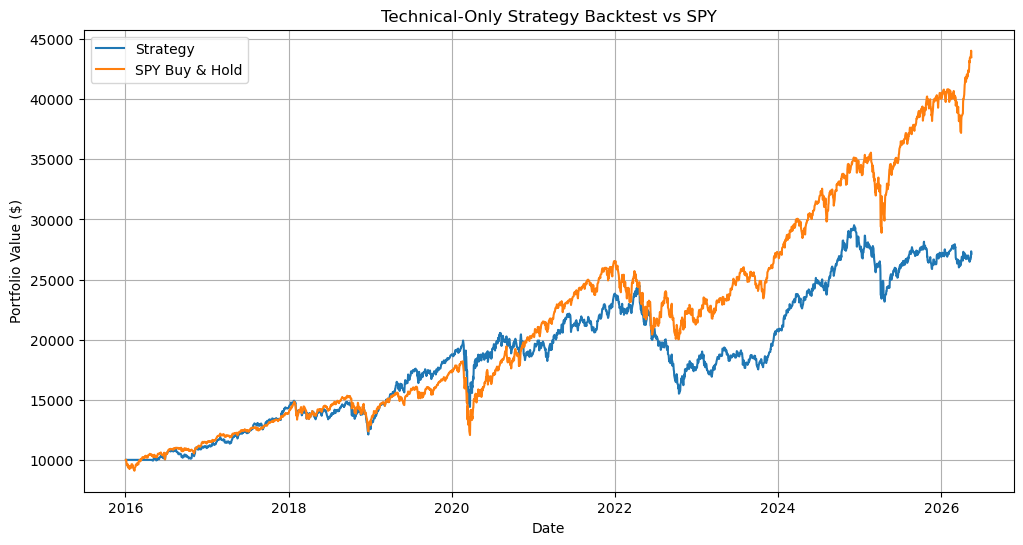

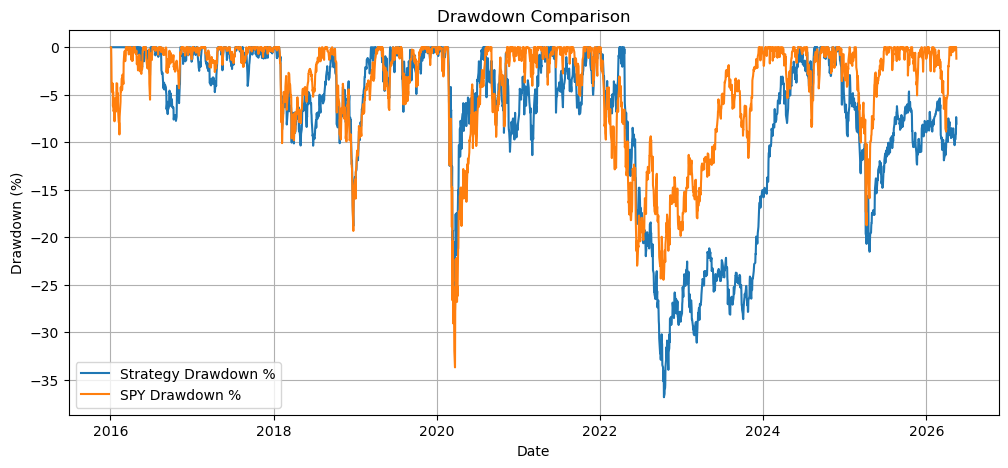

In [290]:
# %%
# ============================================================
# SECTION 13: TECHNICAL-ONLY BACKTEST VS SPY
# Uses BACKTEST_2016_UNIVERSE from Section 1
# Gemini/news API is NOT used
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

print("Starting technical-only backtest...")
print("Gemini/news API is NOT used in this backtest.")

# ------------------------------------------------------------
# 13A: Backtest settings
# ------------------------------------------------------------

BACKTEST_START = "2016-01-01"
BACKTEST_END = None

BACKTEST_INITIAL_CASH = 10_000
BACKTEST_MAX_POSITIONS = 5
BACKTEST_POSITION_SIZE_PCT = 1 / BACKTEST_MAX_POSITIONS

REBALANCE_EVERY_N_DAYS = 5
BACKTEST_TRANSACTION_COST_RATE = 0.001

BT_FAST_SMA = 20
BT_SLOW_SMA = 50

BT_MIN_MOMENTUM_20D = 0.03
BT_MAX_VOLATILITY_20D = 0.04

BT_STOP_LOSS_PCT = -0.08
BT_TAKE_PROFIT_PCT = 999

BT_SMOOTHING_SPAN = 10
BT_HIGH_MOMENTUM_THRESHOLD = 0.08
BT_SLOPE_FLAT_THRESHOLD = 0.003
BT_MIN_PROFIT_FOR_DERIVATIVE_SELL = 0.03

# False = do not sell just because stock becomes WATCHLIST / no longer BUY
BT_SELL_WHEN_NOT_BUY = False

# ------------------------------------------------------------
# 13B: Use 2016 universe from Section 1
# ------------------------------------------------------------

if "BACKTEST_2016_UNIVERSE" not in globals():
    raise ValueError("BACKTEST_2016_UNIVERSE not found. Run Section 1 first.")

BACKTEST_TICKERS = sorted(list(BACKTEST_2016_UNIVERSE.keys()))

print(f"Backtest universe size: {len(BACKTEST_TICKERS)}")
print(f"Backtest start date: {BACKTEST_START}")

# ------------------------------------------------------------
# 13C: Download historical data
# ------------------------------------------------------------

download_tickers = sorted(list(set(BACKTEST_TICKERS + ["SPY"])))

raw_data = yf.download(
    download_tickers,
    start=BACKTEST_START,
    end=BACKTEST_END,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

print("Raw downloaded data shape:", raw_data.shape)

def extract_yfinance_field(raw, field):
    if isinstance(raw.columns, pd.MultiIndex):
        level_0 = raw.columns.get_level_values(0)
        level_1 = raw.columns.get_level_values(1)

        if field in level_0:
            return raw[field].copy()
        elif field in level_1:
            return raw.xs(field, axis=1, level=1).copy()
        else:
            raise ValueError(f"Could not find field: {field}")
    else:
        if field in raw.columns:
            return raw[[field]].copy()
        else:
            raise ValueError(f"Could not find field: {field}")

close_df = extract_yfinance_field(raw_data, "Close")
volume_df = extract_yfinance_field(raw_data, "Volume")

# Keep tickers with enough data
MIN_REQUIRED_DAYS = 252 * 5

valid_tickers = []

for ticker in close_df.columns:
    valid_days = close_df[ticker].dropna().shape[0]
    if valid_days >= MIN_REQUIRED_DAYS:
        valid_tickers.append(ticker)

close_df = close_df[valid_tickers].copy().ffill()
volume_df = volume_df[valid_tickers].copy().ffill()

if "SPY" not in close_df.columns:
    raise ValueError("SPY missing. Cannot benchmark.")

print(f"Valid tickers after cleaning: {len(valid_tickers)}")

# ------------------------------------------------------------
# 13D: Technical indicators
# ------------------------------------------------------------

returns_df = close_df.pct_change()

sma_fast = close_df.rolling(BT_FAST_SMA).mean()
sma_slow = close_df.rolling(BT_SLOW_SMA).mean()

momentum_20d = close_df / close_df.shift(20) - 1
volatility_20d = returns_df.rolling(20).std()

avg_volume_20d = volume_df.shift(1).rolling(20).mean()
volume_ratio = volume_df.shift(1) / avg_volume_20d

technical_score = (
    0.45 * momentum_20d.rank(axis=1, pct=True)
    + 0.25 * (1 - volatility_20d.rank(axis=1, pct=True))
    + 0.20 * volume_ratio.rank(axis=1, pct=True)
    + 0.10 * (close_df > sma_fast).astype(float)
)

technical_buy_signal = (
    (close_df > sma_fast)
    & (sma_fast > sma_slow)
    & (momentum_20d > BT_MIN_MOMENTUM_20D)
    & (volatility_20d < BT_MAX_VOLATILITY_20D)
)

print("Technical indicators calculated.")

# ------------------------------------------------------------
# 13E: Derivative / double-derivative sell signal
# ------------------------------------------------------------

smooth_close_df = close_df.ewm(span=BT_SMOOTHING_SPAN).mean()

slope_df = smooth_close_df.pct_change()
acceleration_df = slope_df.diff()

momentum_for_derivative = close_df / close_df.shift(20) - 1

derivative_sell_signal = (
    (momentum_for_derivative > BT_HIGH_MOMENTUM_THRESHOLD)
    & (slope_df > 0)
    & (slope_df < BT_SLOPE_FLAT_THRESHOLD)
    & (acceleration_df < 0)
)

print("Derivative sell signals calculated.")

# ------------------------------------------------------------
# 13F: Backtest engine
# ------------------------------------------------------------

def run_technical_backtest():
    cash = BACKTEST_INITIAL_CASH
    positions = {}
    trade_log = []
    equity_curve = []

    dates = close_df.index
    warmup_days = max(BT_SLOW_SMA, 80)

    for i, current_date in enumerate(dates):
        prices_today = close_df.loc[current_date]

        if i < warmup_days:
            equity_curve.append({
                "Date": current_date,
                "Equity": cash,
                "Cash": cash,
                "Positions_Value": 0.0,
                "Num_Positions": 0
            })
            continue

        positions_value = 0.0

        for ticker, pos in positions.items():
            price = prices_today.get(ticker, np.nan)
            if pd.notna(price) and price > 0:
                positions_value += pos["shares"] * price

        equity = cash + positions_value
        should_rebalance = (i % REBALANCE_EVERY_N_DAYS == 0)

        if should_rebalance:
            tickers_to_sell = []

            for ticker, pos in list(positions.items()):
                price = prices_today.get(ticker, np.nan)

                if pd.isna(price) or price <= 0:
                    continue

                position_return = (price / pos["avg_price"]) - 1

                is_buy = bool(technical_buy_signal.loc[current_date].get(ticker, False))
                derivative_sell = bool(derivative_sell_signal.loc[current_date].get(ticker, False))

                sell_reason = None

                if position_return <= BT_STOP_LOSS_PCT:
                    sell_reason = "Stop loss"

                elif position_return >= BT_TAKE_PROFIT_PCT:
                    sell_reason = "Take profit"

                elif position_return >= BT_MIN_PROFIT_FOR_DERIVATIVE_SELL and derivative_sell:
                    sell_reason = "Derivative exhaustion sell"

                elif BT_SELL_WHEN_NOT_BUY and not is_buy:
                    sell_reason = "No longer BUY"

                if sell_reason is not None:
                    tickers_to_sell.append((ticker, sell_reason))

            # Execute sells
            for ticker, reason in tickers_to_sell:
                if ticker not in positions:
                    continue

                price = prices_today.get(ticker, np.nan)

                if pd.isna(price) or price <= 0:
                    continue

                shares = positions[ticker]["shares"]
                proceeds = shares * price
                cost = proceeds * BACKTEST_TRANSACTION_COST_RATE

                cash += proceeds - cost

                trade_log.append({
                    "Date": current_date,
                    "Ticker": ticker,
                    "Action": "SELL",
                    "Price": price,
                    "Shares": shares,
                    "Value": proceeds,
                    "Cost": cost,
                    "Reason": reason
                })

                del positions[ticker]

            # Recalculate equity after sells
            positions_value = 0.0

            for ticker, pos in positions.items():
                price = prices_today.get(ticker, np.nan)
                if pd.notna(price) and price > 0:
                    positions_value += pos["shares"] * price

            equity = cash + positions_value

            # Buy logic
            scores_today = technical_score.loc[current_date].dropna()
            buy_signal_today = technical_buy_signal.loc[current_date]

            candidate_tickers = [
                ticker for ticker in scores_today.index
                if ticker != "SPY"
                and ticker not in positions
                and bool(buy_signal_today.get(ticker, False))
            ]

            ranked_candidates = scores_today.loc[candidate_tickers].sort_values(ascending=False)

            available_slots = BACKTEST_MAX_POSITIONS - len(positions)

            if available_slots > 0 and cash > 20:
                selected_buys = ranked_candidates.head(available_slots)

                for ticker, score in selected_buys.items():
                    price = prices_today.get(ticker, np.nan)

                    if pd.isna(price) or price <= 0:
                        continue

                    target_value = equity * BACKTEST_POSITION_SIZE_PCT
                    buy_value = min(cash, target_value)

                    if buy_value <= 20:
                        continue

                    cost = buy_value * BACKTEST_TRANSACTION_COST_RATE
                    net_buy_value = buy_value - cost
                    shares = net_buy_value / price

                    cash -= buy_value

                    positions[ticker] = {
                        "shares": shares,
                        "avg_price": price,
                        "entry_date": current_date
                    }

                    trade_log.append({
                        "Date": current_date,
                        "Ticker": ticker,
                        "Action": "BUY",
                        "Price": price,
                        "Shares": shares,
                        "Value": buy_value,
                        "Cost": cost,
                        "Reason": "Technical buy signal"
                    })

        # End-of-day equity
        positions_value = 0.0

        for ticker, pos in positions.items():
            price = prices_today.get(ticker, np.nan)
            if pd.notna(price) and price > 0:
                positions_value += pos["shares"] * price

        equity = cash + positions_value

        equity_curve.append({
            "Date": current_date,
            "Equity": equity,
            "Cash": cash,
            "Positions_Value": positions_value,
            "Num_Positions": len(positions)
        })

    equity_df = pd.DataFrame(equity_curve).set_index("Date")
    trades_df = pd.DataFrame(trade_log)

    return equity_df, trades_df

equity_df, trades_df = run_technical_backtest()

print("Backtest complete.")
print(f"Number of trades: {len(trades_df)}")

display(equity_df.tail())
display(trades_df.tail(20))

# ------------------------------------------------------------
# 13G: Stats and SPY comparison
# ------------------------------------------------------------

def calculate_backtest_stats(equity_series):
    equity_series = equity_series.dropna()
    daily_returns = equity_series.pct_change().dropna()

    total_return = (equity_series.iloc[-1] / equity_series.iloc[0]) - 1

    running_max = equity_series.cummax()
    drawdown = (equity_series / running_max) - 1
    max_drawdown = drawdown.min()

    if daily_returns.std() > 0:
        sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
    else:
        sharpe = np.nan

    years = (equity_series.index[-1] - equity_series.index[0]).days / 365.25

    if years > 0:
        cagr = (equity_series.iloc[-1] / equity_series.iloc[0]) ** (1 / years) - 1
    else:
        cagr = np.nan

    return {
        "Final Value": equity_series.iloc[-1],
        "Total Return %": total_return * 100,
        "CAGR %": cagr * 100,
        "Max Drawdown %": max_drawdown * 100,
        "Sharpe": sharpe
    }

strategy_stats = calculate_backtest_stats(equity_df["Equity"])

spy_prices = close_df["SPY"].dropna()
spy_prices = spy_prices.loc[equity_df.index.intersection(spy_prices.index)]

spy_equity = BACKTEST_INITIAL_CASH * (spy_prices / spy_prices.iloc[0])
spy_equity = spy_equity.reindex(equity_df.index).ffill()

spy_stats = calculate_backtest_stats(spy_equity)

comparison_df = pd.DataFrame({
    "Strategy": strategy_stats,
    "SPY Buy & Hold": spy_stats
})

display(comparison_df)

# ------------------------------------------------------------
# 13H: Trade diagnostics
# ------------------------------------------------------------

if not trades_df.empty:
    buys = trades_df[trades_df["Action"] == "BUY"]
    sells = trades_df[trades_df["Action"] == "SELL"]

    print("\nTRADE DIAGNOSTICS")
    print("-----------------")
    print(f"Buy trades: {len(buys)}")
    print(f"Sell trades: {len(sells)}")

    if len(sells) > 0:
        print("\nSell reasons:")
        print(sells["Reason"].value_counts())
else:
    print("No trades were made.")

# ------------------------------------------------------------
# 13I: Equity curve
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
plt.plot(equity_df.index, equity_df["Equity"], label="Strategy")
plt.plot(spy_equity.index, spy_equity, label="SPY Buy & Hold")
plt.title("Technical-Only Strategy Backtest vs SPY")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 13J: Drawdown plot
# ------------------------------------------------------------

strategy_drawdown = (equity_df["Equity"] / equity_df["Equity"].cummax()) - 1
spy_drawdown = (spy_equity / spy_equity.cummax()) - 1

plt.figure(figsize=(12, 5))
plt.plot(strategy_drawdown.index, strategy_drawdown * 100, label="Strategy Drawdown %")
plt.plot(spy_drawdown.index, spy_drawdown * 100, label="SPY Drawdown %")
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.show()